In [1]:
pip install "stable-baselines3[extra]>=2.0.0" rl_zoo3 gymnasium

Note: you may need to restart the kernel to use updated packages.


# Loading Pretrained DQN Model


In [2]:
import sys
import gymnasium as gym

sys.modules["gym"] = gym

from stable_baselines3 import DQN
from huggingface_sb3 import load_from_hub

ckpt = load_from_hub(
    repo_id="sb3/dqn-Acrobot-v1",
    filename="dqn-Acrobot-v1.zip",
)

env = gym.make("Acrobot-v1")

custom_objects = {
    "observation_space": env.observation_space,
    "action_space": env.action_space
}

model = DQN.load(
    ckpt,
    env=env,
    custom_objects=custom_objects
)

print("\n✓ Model loaded successfully with custom objects")

c:\Users\DELL\anaconda3\Lib\site-packages\stable_baselines3\common\save_util.py:167: UserWarning: Could not deserialize object learning_rate. Consider using `custom_objects` argument to replace this object.
Exception: code expected at least 16 arguments, got 15
  warnings.warn(
c:\Users\DELL\anaconda3\Lib\site-packages\stable_baselines3\common\save_util.py:167: UserWarning: Could not deserialize object lr_schedule. Consider using `custom_objects` argument to replace this object.
Exception: code expected at least 16 arguments, got 15
  warnings.warn(
c:\Users\DELL\anaconda3\Lib\site-packages\stable_baselines3\common\save_util.py:167: UserWarning: Could not deserialize object exploration_schedule. Consider using `custom_objects` argument to replace this object.
Exception: code expected at least 16 arguments, got 15
  warnings.warn(


Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.

✓ Model loaded successfully with custom objects


c:\Users\DELL\anaconda3\Lib\site-packages\stable_baselines3\common\base_class.py:773: UserWarning: You are probably loading a DQN model saved with SB3 < 2.4.0, we truncated the optimizer state so you can save the model again to avoid issues in the future (see https://github.com/DLR-RM/stable-baselines3/pull/1963 for more info). Original error: loaded state dict contains a parameter group that doesn't match the size of optimizer's group 
Note: the model should still work fine, this only a warning.
  warnings.warn(


# Inspecting the Neural Network Architecture


In [3]:
# styling for cell output
print("\n" + "─" * 50)
print("   NETWORK ARCHITECTURE - ACROBOT")
print("─" * 50)
#----------------------------------------------------

print(f"\nPolicy type   : {type(model.policy).__name__} \n")

# show Full Q-Network structure
q_net = model.q_net
print("Full Q-Network structure:")
print(q_net)

# more Details about the input and output
print(
    f"\n Input size    : {env.observation_space.shape[0]} \n "
    f"(cosθ1, sinθ1, cosθ2, sinθ2, angular velocities)"
)

print(
    f"\n Output size   : {env.action_space.n}  "
    f"(Torque Left | No Torque | Torque Right)\n"
)




print("\nQ-Network layers summary:")

print(
    "   Input(6)  →  Dense(256, ReLU)  →  "
    "Dense(256, ReLU)  →  Output(3)"
)

print()


──────────────────────────────────────────────────
   NETWORK ARCHITECTURE - ACROBOT
──────────────────────────────────────────────────

Policy type   : DQNPolicy 

Full Q-Network structure:
QNetwork(
  (features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (q_net): Sequential(
    (0): Linear(in_features=6, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=3, bias=True)
  )
)

 Input size    : 6 
 (cosθ1, sinθ1, cosθ2, sinθ2, angular velocities)

 Output size   : 3  (Torque Left | No Torque | Torque Right)


Q-Network layers summary:
   Input(6)  →  Dense(256, ReLU)  →  Dense(256, ReLU)  →  Output(3)



# Displaying Hyperparameters


In [4]:
print("\n" + "─" * 60)
print("   HYPERPARAMETERS (from sb3/dqn-Acrobot-v1 model card)")
print("─" * 60)

#------------------------------------------------------
params = {

    # Experience Replay
    "buffer_size"            : (model.buffer_size,              "Experience Replay"),
    "batch_size"             : (model.batch_size,               "Experience Replay"),
    "learning_starts"        : (model.learning_starts,          "Experience Replay"),
    "train_freq"             : (model.train_freq,               "Experience Replay"),
    "gradient_steps"         : (model.gradient_steps,           "Experience Replay"),

    # Target Network
    "target_update_interval" : (model.target_update_interval,   "Target Network"),

    # Exploration (ε-greedy)
    "exploration_fraction"   : (model.exploration_fraction,     "Exploration"),
    "exploration_final_eps"  : (model.exploration_final_eps,    "Exploration"),
    "exploration_rate"       : (model.exploration_rate,         "Exploration"),

    # Core RL
    "gamma"                  : (model.gamma,                    "Core RL"),
    "learning_rate"          : (model.learning_rate,            "Core RL"),
}

# learning_starts = 0  ===> The environment is relatively small OR The initial experiences are sufficient for learning. 


# the way to print Hyperparameters

categories = {}

for name, (val, cat) in params.items():
    categories.setdefault(cat, []).append((name, val))

for cat, items in categories.items():

    print(f"\n  [{cat}]")

    for name, val in items:
        print(f"    {name:<28} = {val}")

        

print("\n" + "─" * 60)


────────────────────────────────────────────────────────────
   HYPERPARAMETERS (from sb3/dqn-Acrobot-v1 model card)
────────────────────────────────────────────────────────────

  [Experience Replay]
    buffer_size                  = 1
    batch_size                   = 128
    learning_starts              = 0
    train_freq                   = TrainFreq(frequency=4, unit=<TrainFrequencyUnit.STEP: 'step'>)
    gradient_steps               = -1

  [Target Network]
    target_update_interval       = 250

  [Exploration]
    exploration_fraction         = 0.12
    exploration_final_eps        = 0.1
    exploration_rate             = 0.1

  [Core RL]
    gamma                        = 0.99
    learning_rate                = 0.0001

────────────────────────────────────────────────────────────


# Recording the Pretrained Agent


In [5]:
# imageio need ffmpeg to transform frames to mp4

!pip install imageio[ffmpeg]

import gymnasium as gym
import imageio.v2 as imageio
from IPython.display import Video, display


#Instead of displaying the game directly on the screen:
#the environment returns each frame as an RGB image.
#And this is necessary for recording the video.

env = gym.make("Acrobot-v1", render_mode="rgb_array")


all_frames = []
num_episodes = 5

print(f"Recording {num_episodes} episodes of Acrobot...")

for i in range(num_episodes):

    obs, info = env.reset()
    done = False
    score = 0

    while not done:
        action, _ = model.predict(obs, deterministic=True)

        obs, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated
        score += reward

        frame = env.render()
        all_frames.append(frame)

    print(f"Episode {i+1} finished! Total Reward: {score:.2f}")

env.close()

video_path = "acrobot_pretrained.mp4"

with imageio.get_writer(video_path, fps=15, format="FFMPEG") as writer:
    for frame in all_frames:
        writer.append_data(frame)

print(f"\nVideo saved to {video_path}")

display(Video(video_path, embed=True, width=600))

Recording 5 episodes of Acrobot...
Episode 1 finished! Total Reward: -80.00
Episode 2 finished! Total Reward: -69.00
Episode 3 finished! Total Reward: -78.00
Episode 4 finished! Total Reward: -70.00
Episode 5 finished! Total Reward: -94.00


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (500, 500) to (512, 512) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).



Video saved to acrobot_pretrained.mp4


# Implementing Early Stopping Callback


In [6]:
import gymnasium as gym
from stable_baselines3 import DQN
from stable_baselines3.common.utils import get_linear_fn
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.evaluation import evaluate_policy
import numpy as np
import copy

# ── Early Stopping + Best Weights Callback ────────────────────
class EarlyStoppingBestWeights(BaseCallback):
    """
    Evaluates every `eval_freq` steps.
    - Saves best policy weights in memory.
    - Stops training if no improvement for `patience` evaluations.
    - Stops if score stays below `min_reward` (stagnates) for `floor_patience` consecutive evals.
    """
    def __init__(
        self,
        eval_env,
        eval_freq       = 1000,    
        n_eval_episodes = 10,     
        min_reward      = -115,   
        patience        = 10,
        floor_patience  = 5,
        verbose         = True,
    ):
        super().__init__(verbose)
        self.eval_env         = eval_env
        self.eval_freq        = eval_freq
        self.n_eval_episodes  = n_eval_episodes
        self.patience         = patience
        self.min_reward       = min_reward
        self.floor_patience   = floor_patience

        self.best_mean_reward   = -np.inf
        self.best_weights       = None
        self.no_improve_count   = 0
        self.below_floor_count  = 0  
        self.eval_history       = []

    def _on_step(self) -> bool:
        if self.n_calls % self.eval_freq != 0:
            return True

        mean, std = evaluate_policy(
            self.model, self.eval_env,
            n_eval_episodes = self.n_eval_episodes,
            deterministic   = True,
        )
        self.eval_history.append((self.num_timesteps, mean, std))

        
        improved = mean > self.best_mean_reward + 0.5

       
        if improved:
            self.best_mean_reward = mean
            self.best_weights     = copy.deepcopy(self.model.policy.state_dict())
            self.no_improve_count = 0
            tag = "✓ NEW BEST"
        else:
            self.no_improve_count += 1
            tag = f"✗ no improvement ({self.no_improve_count}/{self.patience})"

        
        if mean < self.min_reward:
            self.below_floor_count += 1
            tag += f"  |  ⚠ Still below target ({self.below_floor_count}/{self.floor_patience})"
        else:
            self.below_floor_count = 0  
            tag += "  |  ★ Target Reached ★"

        if self.verbose:
            print(f"  │  [{self.num_timesteps:>7,}]  reward: {mean:7.2f} ± {std:.2f}  {tag}")

        
        if self.below_floor_count >= self.floor_patience:
            print(f"  │  ⚠ Reward stayed below {self.min_reward} for {self.floor_patience} consecutive evals — stopping.")
            return False

        if self.no_improve_count >= self.patience:
            print(f"  │  ⚠ No improvement for {self.patience} evals — early stopping")
            return False

        return True

    def restore_best_weights(self):
        if self.best_weights is not None:
            self.model.policy.load_state_dict(self.best_weights)
            print(f"  │  ✓ Best weights restored  (reward: {self.best_mean_reward:.2f})")
        else:
            print(f"  │  ⚠ No best weights saved — model unchanged")

# Rebuilding the Replay Buffer


In [7]:
import gymnasium as gym 
from stable_baselines3 import DQN
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.utils import get_linear_fn

def buf_len(model):
    rb = model.replay_buffer
    return rb.buffer_size if rb.full else rb.pos


ft_env = gym.make("Acrobot-v1")


ft_model = DQN.load(ckpt, env=ft_env, custom_objects=custom_objects)


REPLAY_BUFFER_SIZE = 20000 
ft_model.buffer_size = REPLAY_BUFFER_SIZE
ft_model.replay_buffer = ft_model.replay_buffer.__class__(
    REPLAY_BUFFER_SIZE,
    ft_model.observation_space,
    ft_model.action_space,
    device=ft_model.device,
    optimize_memory_usage=ft_model.optimize_memory_usage,
)


ft_model.exploration_rate = 0.02
ft_model.exploration_schedule = get_linear_fn(0.02, 0.02, 1.0)

print(f"    Loaded Acrobot model diagnostics:")
print(f"    epsilon             : {ft_model.exploration_rate:.4f}")
print(f"    Replay buffer       : {buf_len(ft_model):,} / {ft_model.buffer_size:,}  ← (READY FOR NEW DATA)")
print(f"    Learning rate       : {ft_model.learning_rate}")

print(f"\n Evaluating pretrained baseline...")
mean_r, std_r = evaluate_policy(
    ft_model,
    ft_env,
    n_eval_episodes=10,
    deterministic=True,
)

print(f"    Current Performance : {mean_r:8.2f} ± {std_r:.2f}")

c:\Users\DELL\anaconda3\Lib\site-packages\stable_baselines3\common\save_util.py:167: UserWarning: Could not deserialize object learning_rate. Consider using `custom_objects` argument to replace this object.
Exception: code expected at least 16 arguments, got 15
  warnings.warn(
c:\Users\DELL\anaconda3\Lib\site-packages\stable_baselines3\common\save_util.py:167: UserWarning: Could not deserialize object lr_schedule. Consider using `custom_objects` argument to replace this object.
Exception: code expected at least 16 arguments, got 15
  warnings.warn(
c:\Users\DELL\anaconda3\Lib\site-packages\stable_baselines3\common\save_util.py:167: UserWarning: Could not deserialize object exploration_schedule. Consider using `custom_objects` argument to replace this object.
Exception: code expected at least 16 arguments, got 15
  warnings.warn(
c:\Users\DELL\anaconda3\Lib\site-packages\stable_baselines3\common\utils.py:193: UserWarning: get_linear_fn() is deprecated, please use LinearSchedule() inste

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
    Loaded Acrobot model diagnostics:
    epsilon             : 0.0200
    Replay buffer       : 0 / 20,000  ← (READY FOR NEW DATA)
    Learning rate       : 0.0001

 Evaluating pretrained baseline...
    Current Performance :   -82.30 ± 12.93


# Fine-Tuning the Pretrained Model first


In [8]:

BUFFER_FILL_STEPS = REPLAY_BUFFER_SIZE

print(f"\n   ┌─ Phase 1: Buffer pre-population (Acrobot) ──")
print(f"   │  Collecting {BUFFER_FILL_STEPS:,} transitions (Gathering Data...)")


ft_model.learning_starts = 10_000_000 

ft_model.learn(
    total_timesteps=REPLAY_BUFFER_SIZE,
    reset_num_timesteps=False,
    log_interval=100,
)

buffer_entries = buf_len(ft_model)
print(f"   │  ✓ Buffer filled : {buffer_entries:,} / {ft_model.buffer_size:,}")

assert buffer_entries >= REPLAY_BUFFER_SIZE * 0.95, "Buffer not filled enough!"
print(f"   └────────────────────────────────────────────────────")

FINE_TUNE_STEPS = 50_000 

pretrain_lr = ft_model.policy.optimizer.param_groups[0]['lr']
finetune_lr = pretrain_lr / 10 
for pg in ft_model.policy.optimizer.param_groups:
    pg['lr'] = finetune_lr

ft_model.lr_schedule = get_linear_fn(finetune_lr, finetune_lr, 1.0)
ft_model.learning_starts = 0 


callback = EarlyStoppingBestWeights(
    eval_env         = ft_env,
    eval_freq        = 1000,   
    n_eval_episodes  = 10,      
    patience         = 10,      
    min_reward       = -75,     
    floor_patience   = 5,      
)

print(f"\n   ┌─ Phase 2: Fine-tuning Acrobot ─────────────")
print(f"   │  Learning Rate: {pretrain_lr} → {finetune_lr}")
print(f"   │  Target Reward: > -75 (Elite Performance)")
print(f"   │──────────────────────────────────────────────────")

ft_model.learn(
    total_timesteps=FINE_TUNE_STEPS,
    reset_num_timesteps=False,
    log_interval=100,
    callback=callback,
)

callback.restore_best_weights()
print(f"   └────────────────────────────────────────────────────")


print(f"\n 📊 Running final 100-episode verification...")

mean_ft, std_ft = evaluate_policy(
    ft_model,
    ft_env,
    n_eval_episodes=100,
    deterministic=True,
)

print(f"\n   ┌─ Final Results (Acrobot) ──────────────────")
print(f"   │  Pretrained  : {mean_r:8.2f}")
print(f"   │  Fine-tuned  : {mean_ft:8.2f} ± {std_ft:.2f}")

if mean_ft >= -80:
    status = "✓ SOLVED (Elite Gymnast)"
elif mean_ft >= -120:
    status = "✓ SAFE (Effective Swing-up)"
else:
    status = "✗ NEEDS WORK (Too many steps)"

print(f"   │  Status      : {status}")
print(f"   └────────────────────────────────────────────────────")

ft_model.save("acrobot_dqn_finetuned.zip")
print(f"\n💾 Saved → acrobot_dqn_finetuned.zip")

ft_env.close()
print("\n✨ Done! Your Acrobot is now a pro gymnast!")


   ┌─ Phase 1: Buffer pre-population (Acrobot) ──
   │  Collecting 20,000 transitions (Gathering Data...)
   │  ✓ Buffer filled : 20,000 / 20,000
   └────────────────────────────────────────────────────

   ┌─ Phase 2: Fine-tuning Acrobot ─────────────
   │  Learning Rate: 0.00063 → 6.3e-05
   │  Target Reward: > -75 (Elite Performance)
   │──────────────────────────────────────────────────
  │  [121,000]  reward:  -80.70 ± 26.57  ✓ NEW BEST  |  ⚠ Still below target (1/5)
  │  [122,000]  reward:  -78.30 ± 17.70  ✓ NEW BEST  |  ⚠ Still below target (2/5)
  │  [123,000]  reward:  -82.30 ± 18.27  ✗ no improvement (1/10)  |  ⚠ Still below target (3/5)
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 248      |
|    ep_rew_mean      | -248     |
|    exploration_rate | 0.02     |
| time/               |          |
|    episodes         | 1100     |
|    fps              | 156      |
|    time_elapsed     | 24       |
|    total_timesteps  | 1239

# Fine-Tuning the Pretrained Model second


In [9]:
ckpt = "acrobot_dqn_finetuned.zip" 
ft_env = gym.make("Acrobot-v1")
ft_model = DQN.load(ckpt, env=ft_env, custom_objects=custom_objects)


REPLAY_BUFFER_SIZE = 20_000
ft_model.buffer_size = REPLAY_BUFFER_SIZE
ft_model.replay_buffer = ft_model.replay_buffer.__class__(
    REPLAY_BUFFER_SIZE,
    ft_model.observation_space,
    ft_model.action_space,
    device=ft_model.device,
    optimize_memory_usage=ft_model.optimize_memory_usage,
)


ft_model.exploration_rate = 0.02 
ft_model.exploration_schedule = get_linear_fn(0.02, 0.02, 1.0)

print(f"    Acrobot Fine-Tuning Diagnostics:")
print(f"    epsilon             : {ft_model.exploration_rate:.4f}")
print(f"    Replay buffer       : EMPTY (Ready for Phase 1)")

print(f"\n Evaluating current model...")
mean_r, std_r = evaluate_policy(ft_model, ft_env, n_eval_episodes=20, deterministic=True)
print(f"    Current Baseline : {mean_r:8.2f} ± {std_r:.2f}")


BUFFER_FILL_STEPS = REPLAY_BUFFER_SIZE
print(f"\n   ┌─ Phase 1: Gathering new swing-up data ──────────────────")
ft_model.learning_starts = 10_000_000 
ft_model.learn(total_timesteps=BUFFER_FILL_STEPS, reset_num_timesteps=False, log_interval=100)
print(f"   │  ✓ Buffer filled with {buf_len(ft_model):,} transitions")
print(f"   └────────────────────────────────────────────────────")


FINE_TUNE_STEPS = 50_000


finetune_lr = ft_model.policy.optimizer.param_groups[0]['lr'] / 10
ft_model.lr_schedule = get_linear_fn(finetune_lr, finetune_lr, 1.0)
ft_model.gradient_steps = 1
ft_model.learning_starts = 0 


callback = EarlyStoppingBestWeights(
    eval_env         = ft_env,
    eval_freq        = 1500,
    n_eval_episodes  = 10,
    patience         = 15,
 
    min_reward       = max(mean_r + 5, -80), 
    floor_patience   = 4,
)

print(f"\n   ┌─ Phase 2: Iterative Fine-tuning (Acrobot) ────")
print(f"   │  Targeting improvement over {mean_r:.2f}")
print(f"   │──────────────────────────────────────────────────")

ft_model.learn(total_timesteps=FINE_TUNE_STEPS, reset_num_timesteps=False, log_interval=100, callback=callback)

callback.restore_best_weights()

print(f"\n Official 100-episode verification...")
mean_ft, std_ft = evaluate_policy(ft_model, ft_env, n_eval_episodes=100, deterministic=True)

print(f"\n   ┌─ Final Results (Acrobot-v1) ────────────────")
print(f"   │  Initial     : {mean_r:8.2f}")
print(f"   │  Final       : {mean_ft:8.2f} ± {std_ft:.2f}")

improvement = mean_ft - mean_r
print(f"   │  Improvement : {improvement:+8.2f}")


if mean_ft >= -100:
    print(f"   │  Status      : ✓ ELITE GYMNAST PERFORMANCE")
else:
    print(f"   │  Status      : ~ Stable Swing-up")

print(f"   └────────────────────────────────────────────────────")

ft_model.save("acrobot_final_fine_tuned.zip")
ft_env.close()
print("\nAll Done! Your model is saved as 'acrobot_final_fine_tuned.zip'")

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
    Acrobot Fine-Tuning Diagnostics:
    epsilon             : 0.0200
    Replay buffer       : EMPTY (Ready for Phase 1)

 Evaluating current model...
    Current Baseline :   -66.95 ± 9.40

   ┌─ Phase 1: Gathering new swing-up data ──────────────────
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 241      |
|    ep_rew_mean      | -241     |
|    exploration_rate | 0.02     |
| time/               |          |
|    episodes         | 1400     |
|    fps              | 3021     |
|    time_elapsed     | 6        |
|    total_timesteps  | 163486   |
----------------------------------
   │  ✓ Buffer filled with 20,000 transitions
   └────────────────────────────────────────────────────

   ┌─ Phase 2: Iterative Fine-tuning (Acrobot) ────
   │  Targeting improvement over -66.95
   │──────────────────────────────────────────────────
  │  [165,500]  reward:  -80.40 ±

# Recording Final Agent Performance


In [10]:
import gymnasium as gym
from stable_baselines3 import DQN
import imageio.v2 as imageio
from IPython.display import Video, display


try:
    model = DQN.load("acrobot_final_fine_tuned.zip")
except:
    model = DQN.load(
        "acrobot_final_fine_tuned.zip",
        custom_objects=custom_objects
    )


env = gym.make("Acrobot-v1", render_mode="rgb_array")

all_frames = []

num_episodes = 5

print(f"Recording {num_episodes} episodes of your Final Acrobot model...")


for i in range(num_episodes):
    obs, info = env.reset()
    done = False
    score = 0

    while not done:
        
        action, _ = model.predict(obs, deterministic=True)

      
        obs, reward, terminated, truncated, info = env.step(action)

        done = terminated or truncated
        score += reward

   
        all_frames.append(env.render())

    print(f"Episode {i+1} finished with score: {score:.2f}")

env.close()


video_path = "acrobot_expert_performance.mp4"

with imageio.get_writer(
    video_path,
    fps=15,
    format="FFMPEG",
    macro_block_size=1
) as writer:
    for frame in all_frames:
        writer.append_data(frame)

print(f"\nVideo saved as {video_path}")


display(
    Video(
        video_path,
        embed=True,
        html_attributes="controls autoplay loop",
        width=600
    )
)

Recording 5 episodes of your Final Acrobot model...
Episode 1 finished with score: -70.00
Episode 2 finished with score: -80.00
Episode 3 finished with score: -62.00
Episode 4 finished with score: -83.00
Episode 5 finished with score: -61.00

Video saved as acrobot_expert_performance.mp4


## Evaluation and Reward comparison 

In [11]:
import sys
import gymnasium as gym
import numpy as np

from stable_baselines3 import DQN
from huggingface_sb3 import load_from_hub


# =====================================
# FIX FOR GYM / GYMNASIUM COMPATIBILITY
# =====================================
sys.modules["gym"] = gym


# =====================================
# LOAD BASELINE MODEL (FROM HUB)
# =====================================

print("\nLoading baseline model from HuggingFace...")

ckpt = load_from_hub(
    repo_id="sb3/dqn-Acrobot-v1",
    filename="dqn-Acrobot-v1.zip",
)

env = gym.make("Acrobot-v1")

custom_objects = {
    "observation_space": env.observation_space,
    "action_space": env.action_space
}

baseline_model = DQN.load(
    ckpt,
    env=env,
    custom_objects=custom_objects
)

print("✓ Baseline model loaded")


# =====================================
# LOAD FINE-TUNED MODEL (LOCAL)
# =====================================

print("\nLoading fine-tuned model...")

ft_env = gym.make("Acrobot-v1")

fine_tuned_model = DQN.load(
    "acrobot_final_fine_tuned",
    env=ft_env
)

print("✓ Fine-tuned model loaded")


# =====================================
# EVALUATION FUNCTION
# =====================================

def evaluate_model(model, env_id="Acrobot-v1", n_episodes=20, seed=42):

    env = gym.make(env_id)

    rewards = []
    lengths = []

    for ep in range(n_episodes):

        obs, _ = env.reset(seed=seed + ep)

        done = False
        total_reward = 0
        steps = 0

        while not done:

            action, _ = model.predict(obs, deterministic=True)

            obs, reward, terminated, truncated, _ = env.step(action)

            total_reward += reward
            steps += 1

            done = terminated or truncated

        rewards.append(total_reward)
        lengths.append(steps)

    env.close()

    print("\n=====================================")
    print("Evaluation Results")
    print("=====================================")

    print(f"Average Reward : {np.mean(rewards):.2f}")
    print(f"Max Reward     : {np.max(rewards):.2f}")
    print(f"Min Reward     : {np.min(rewards):.2f}")
    print(f"Reward Std Dev : {np.std(rewards):.2f}")
    print(f"Average Steps  : {np.mean(lengths):.2f}")

    return np.array(rewards), np.array(lengths)


# =====================================
# BASELINE EVALUATION
# =====================================

print("\n================ BASELINE MODEL ================")

baseline_rewards, baseline_lengths = evaluate_model(
    baseline_model,
    n_episodes=20
)


# =====================================
# FINE-TUNED EVALUATION
# =====================================

print("\n================ FINE-TUNED MODEL ================")

ft_rewards, ft_lengths = evaluate_model(
    fine_tuned_model,
    n_episodes=20
)


# =====================================
# FINAL COMPARISON
# =====================================

print("\n=====================================")
print("FINAL COMPARISON")
print("=====================================")

baseline_avg = np.mean(baseline_rewards)
ft_avg = np.mean(ft_rewards)

print(f"Baseline Avg Reward    : {baseline_avg:.2f}")
print(f"Fine-tuned Avg Reward  : {ft_avg:.2f}")

print(f"\nBaseline Avg Steps     : {np.mean(baseline_lengths):.2f}")
print(f"Fine-tuned Avg Steps   : {np.mean(ft_lengths):.2f}")

reward_improvement = ft_avg - baseline_avg

print(f"\nReward Improvement: {reward_improvement:.2f}")

if baseline_avg != 0:
    print(f"Improvement %: {(reward_improvement / abs(baseline_avg)) * 100:.2f}%")

print("\nRESULT:")

if reward_improvement > 0:
    print("✓ Fine-tuned model is BETTER")
elif reward_improvement < 0:
    print("✗ Fine-tuned model is WORSE")
else:
    print("= Both models are equal")


Loading baseline model from HuggingFace...
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
✓ Baseline model loaded

Loading fine-tuned model...
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
✓ Fine-tuned model loaded

================ BASELINE MODEL ================

Evaluation Results
Average Reward : -76.90
Max Reward     : -62.00
Min Reward     : -103.00
Reward Std Dev : 10.32
Average Steps  : 77.90

================ FINE-TUNED MODEL ================

Evaluation Results
Average Reward : -72.55
Max Reward     : -61.00
Min Reward     : -99.00
Reward Std Dev : 11.43
Average Steps  : 73.55

FINAL COMPARISON
Baseline Avg Reward    : -76.90
Fine-tuned Avg Reward  : -72.55

Baseline Avg Steps     : 77.90
Fine-tuned Avg Steps   : 73.55

Reward Improvement: 4.35
Improvement %: 5.66%

RESULT:
✓ Fine-tuned model is BETTER


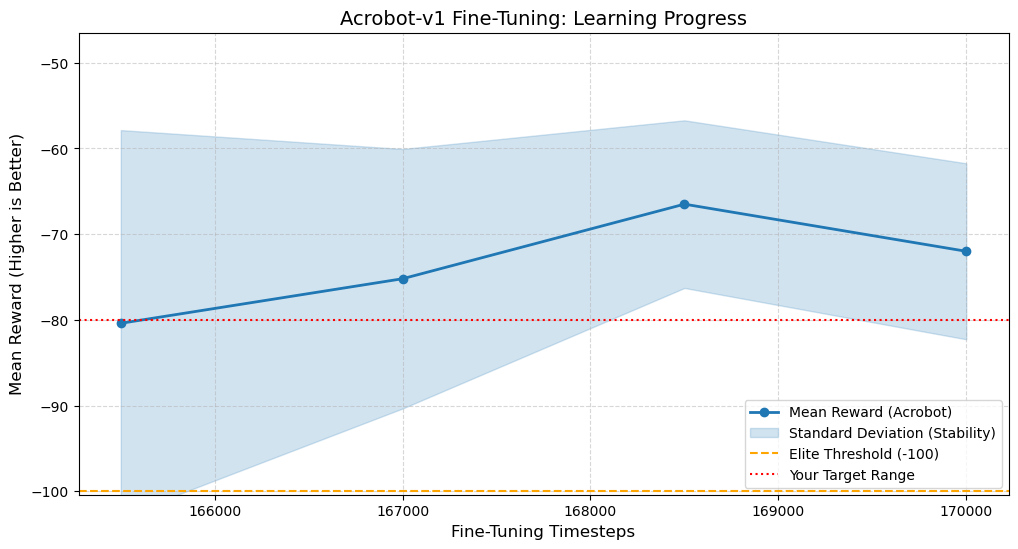

In [12]:
import matplotlib.pyplot as plt


timesteps = [x[0] for x in callback.eval_history]
mean_rewards = [x[1] for x in callback.eval_history]
std_rewards = [x[2] for x in callback.eval_history]

plt.figure(figsize=(12, 6))


plt.plot(timesteps, mean_rewards, marker='o', color='#1f77b4', label='Mean Reward (Acrobot)', linewidth=2)
plt.fill_between(
    timesteps,
    [m - s for m, s in zip(mean_rewards, std_rewards)],
    [m + s for m, s in zip(mean_rewards, std_rewards)],
    color='#1f77b4',
    alpha=0.2,
    label='Standard Deviation (Stability)'
)
plt.axhline(y=-100, color='orange', linestyle='--', label='Elite Threshold (-100)')
plt.axhline(y=-80, color='r', linestyle=':', label='Your Target Range')

plt.xlabel("Fine-Tuning Timesteps", fontsize=12)
plt.ylabel("Mean Reward (Higher is Better)", fontsize=12)
plt.title("Acrobot-v1 Fine-Tuning: Learning Progress", fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(min(mean_rewards) - 20, max(mean_rewards) + 20)

plt.show()